<a href="https://colab.research.google.com/github/kiransree2002/Assessment/blob/main/case_study_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libraries

In [6]:
pip install gensim

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import gensim.downloader as api
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.layers import Input,Dense,Dropout,Concatenate
from tensorflow.keras.models import Model

##Loading Dataset

In [8]:
df_donor = pd.read_csv("/content/drive/MyDrive/Data Set/Preprocessed_DonorsChoose_dataset.csv")
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


###Exploratory Data Analysis (EDA)

In [9]:
df_donor.shape


(109248, 14)

In [10]:
df_donor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [11]:
df_donor.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


In [12]:
df_donor["cleaned_titles"] = df_donor["cleaned_titles"].fillna(" ")

In [13]:
df_donor.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


In [14]:
df_donor.columns

Index(['id', 'teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'cleaned_titles', 'cleaned_essays',
       'cleaned_summary', 'isdigit_summary'],
      dtype='object')

In [15]:
df_donor["project_is_approved"].value_counts()

,count
project_is_approved,
1,92706
0,16542


##NLP Preprocessing

##Removing punchuation

In [16]:
def remove_punctuation(text):
    punctuationless_text = ''.join([i for i in text if i not in string.punctuation])
    return punctuationless_text

In [17]:
import re
import string

def remove_punctuation(text):
    text = str(text)
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply to all three cleaned text columns
text_cols =['id', 'teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'cleaned_titles', 'cleaned_essays',
       'isdigit_summary']

for col in text_cols:
    df_donor[col] = df_donor[col].fillna(" ").apply(remove_punctuation)

In [18]:
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,1546,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,2990,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,51685,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,2329,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,gradesprek2,mathscience,mathematics,1,1,6798,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


##Lowercasing

In [19]:
#checking wheather it has uppercase
text_cols = ['id', 'teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'cleaned_titles', 'cleaned_essays',
       'cleaned_summary', 'isdigit_summary']


for col in text_cols:
    count = df_donor[col].fillna(" ").str.contains(r'[A-Z]', regex=True).sum()
    print(f"{col}: {count} rows contain uppercase letters")


    #there no no uppercase all are lowercase so no need to lowercasing it

id: 0 rows contain uppercase letters
teacher_prefix: 0 rows contain uppercase letters
school_state: 0 rows contain uppercase letters
project_grade_category: 0 rows contain uppercase letters
project_subject_categories: 0 rows contain uppercase letters
project_subject_subcategories: 0 rows contain uppercase letters
teacher_number_of_previously_posted_projects: 0 rows contain uppercase letters
project_is_approved: 0 rows contain uppercase letters
price: 0 rows contain uppercase letters
quantity: 0 rows contain uppercase letters
cleaned_titles: 0 rows contain uppercase letters
cleaned_essays: 0 rows contain uppercase letters
cleaned_summary: 0 rows contain uppercase letters
isdigit_summary: 0 rows contain uppercase letters


In [20]:
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,1546,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,2990,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,51685,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,2329,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,gradesprek2,mathscience,mathematics,1,1,6798,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


###Tokenization


In [21]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
#we convert the entire text into  a list of unique words
#functions to get token from the sentence
#input should be punchation removed and in lower case

def tokenization(text):
  words_list = nltk.word_tokenize(text)
  return words_list

In [23]:
from nltk.tokenize import word_tokenize

text_columns = ["cleaned_titles", "cleaned_essays", "cleaned_summary"]

for col in text_columns:
    df_donor[col] = df_donor[col].str.replace('_', ' ', regex=False)
    df_donor[col + "_tokens"] = df_donor[col].apply(word_tokenize)

In [24]:
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,cleaned_titles_tokens,cleaned_essays_tokens,cleaned_summary_tokens
0,p253737,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,1546,23,educational support english learners home,students english learners working english seco...,students need opportunities practice beginning...,0,"[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi..."
1,p258326,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,2990,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students need projector help viewing education...,0,"[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu..."
2,p182444,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,51685,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students need shine guards athletic socks socc...,0,"[soccer, equipment, awesome, middle, school, s...","[true, champions, not, always, ones, win, guts...","[students, need, shine, guards, athletic, sock..."
3,p246581,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,2329,4,techie kindergarteners,work unique school filled esl english second l...,students need engage reading math way inspire ...,0,"[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i..."
4,p104768,mrs,tx,gradesprek2,mathscience,mathematics,1,1,6798,4,interactive math tools,second grade classroom next year made around 2...,students need hands practice mathematics fun p...,0,"[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,..."


###Stop word Removal

In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [27]:
stop_words_list = nltk.corpus.stopwords.words('english')#corpus means collections
stop_words_list

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

token_columns = [
    "cleaned_titles_tokens",
    "cleaned_essays_tokens",
    "cleaned_summary_tokens"
]

for col in token_columns:
    df_donor[col + "_nostop"] = df_donor[col].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,cleaned_titles_tokens,cleaned_essays_tokens,cleaned_summary_tokens,cleaned_titles_tokens_nostop,cleaned_essays_tokens_nostop,cleaned_summary_tokens_nostop
0,p253737,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,1546,23,educational support english learners home,students english learners working english seco...,students need opportunities practice beginning...,0,"[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi...","[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi..."
1,p258326,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,2990,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students need projector help viewing education...,0,"[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu...","[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu..."
2,p182444,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,51685,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students need shine guards athletic socks socc...,0,"[soccer, equipment, awesome, middle, school, s...","[true, champions, not, always, ones, win, guts...","[students, need, shine, guards, athletic, sock...","[soccer, equipment, awesome, middle, school, s...","[true, champions, always, ones, win, guts, mia...","[students, need, shine, guards, athletic, sock..."
3,p246581,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,2329,4,techie kindergarteners,work unique school filled esl english second l...,students need engage reading math way inspire ...,0,"[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i...","[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i..."
4,p104768,mrs,tx,gradesprek2,mathscience,mathematics,1,1,6798,4,interactive math tools,second grade classroom next year made around 2...,students need hands practice mathematics fun p...,0,"[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,...","[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,..."


##Lemmatization

In [30]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [31]:
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [32]:
stopword_columns = [
    "cleaned_titles_tokens_nostop",
    "cleaned_essays_tokens_nostop",
    "cleaned_summary_tokens_nostop"
]

for col in stopword_columns:
    df_donor[col + "_lemma"] = df_donor[col].apply(lemmatize_tokens)

In [33]:
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,...,isdigit_summary,cleaned_titles_tokens,cleaned_essays_tokens,cleaned_summary_tokens,cleaned_titles_tokens_nostop,cleaned_essays_tokens_nostop,cleaned_summary_tokens_nostop,cleaned_titles_tokens_nostop_lemma,cleaned_essays_tokens_nostop_lemma,cleaned_summary_tokens_nostop_lemma
0,p253737,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,1546,23,...,0,"[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi...","[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi...","[educational, support, english, learner, home]","[student, english, learner, working, english, ...","[student, need, opportunity, practice, beginni..."
1,p258326,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,2990,1,...,0,"[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu...","[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu...","[wanted, projector, hungry, learner]","[student, arrive, school, eager, learn, polite...","[student, need, projector, help, viewing, educ..."
2,p182444,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,51685,22,...,0,"[soccer, equipment, awesome, middle, school, s...","[true, champions, not, always, ones, win, guts...","[students, need, shine, guards, athletic, sock...","[soccer, equipment, awesome, middle, school, s...","[true, champions, always, ones, win, guts, mia...","[students, need, shine, guards, athletic, sock...","[soccer, equipment, awesome, middle, school, s...","[true, champion, always, one, win, gut, mia, h...","[student, need, shine, guard, athletic, sock, ..."
3,p246581,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,2329,4,...,0,"[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i...","[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i...","[techie, kindergartener]","[work, unique, school, filled, esl, english, s...","[student, need, engage, reading, math, way, in..."
4,p104768,mrs,tx,gradesprek2,mathscience,mathematics,1,1,6798,4,...,0,"[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,...","[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,...","[interactive, math, tool]","[second, grade, classroom, next, year, made, a...","[student, need, hand, practice, mathematics, f..."


##Stemming

In [34]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [35]:
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

In [36]:
lemma_columns = [
    "cleaned_titles_tokens_nostop_lemma",
    "cleaned_essays_tokens_nostop_lemma",
    "cleaned_summary_tokens_nostop_lemma"
]

for col in lemma_columns:
    df_donor[col + "_stem"] = df_donor[col].apply(stem_tokens)

In [37]:
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,...,cleaned_summary_tokens,cleaned_titles_tokens_nostop,cleaned_essays_tokens_nostop,cleaned_summary_tokens_nostop,cleaned_titles_tokens_nostop_lemma,cleaned_essays_tokens_nostop_lemma,cleaned_summary_tokens_nostop_lemma,cleaned_titles_tokens_nostop_lemma_stem,cleaned_essays_tokens_nostop_lemma_stem,cleaned_summary_tokens_nostop_lemma_stem
0,p253737,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,1546,23,...,"[students, need, opportunities, practice, begi...","[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi...","[educational, support, english, learner, home]","[student, english, learner, working, english, ...","[student, need, opportunity, practice, beginni...","[educ, support, english, learner, home]","[student, english, learner, work, english, sec...","[student, need, opportun, practic, begin, read..."
1,p258326,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,2990,1,...,"[students, need, projector, help, viewing, edu...","[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu...","[wanted, projector, hungry, learner]","[student, arrive, school, eager, learn, polite...","[student, need, projector, help, viewing, educ...","[want, projector, hungri, learner]","[student, arriv, school, eager, learn, polit, ...","[student, need, projector, help, view, educ, p..."
2,p182444,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,51685,22,...,"[students, need, shine, guards, athletic, sock...","[soccer, equipment, awesome, middle, school, s...","[true, champions, always, ones, win, guts, mia...","[students, need, shine, guards, athletic, sock...","[soccer, equipment, awesome, middle, school, s...","[true, champion, always, one, win, gut, mia, h...","[student, need, shine, guard, athletic, sock, ...","[soccer, equip, awesom, middl, school, student]","[true, champion, alway, one, win, gut, mia, ha...","[student, need, shine, guard, athlet, sock, so..."
3,p246581,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,2329,4,...,"[students, need, engage, reading, math, way, i...","[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i...","[techie, kindergartener]","[work, unique, school, filled, esl, english, s...","[student, need, engage, reading, math, way, in...","[techi, kindergarten]","[work, uniqu, school, fill, esl, english, seco...","[student, need, engag, read, math, way, inspir..."
4,p104768,mrs,tx,gradesprek2,mathscience,mathematics,1,1,6798,4,...,"[students, need, hands, practice, mathematics,...","[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,...","[interactive, math, tool]","[second, grade, classroom, next, year, made, a...","[student, need, hand, practice, mathematics, f...","[interact, math, tool]","[second, grade, classroom, next, year, made, a...","[student, need, hand, practic, mathemat, fun, ..."


##TF-IDF

In [38]:
## Convert Tokens Back to Text

#TF-IDF list of words accept cheyyilla. It requires text strings

df_donor["titles_final"] = df_donor["cleaned_titles_tokens_nostop_lemma_stem"].apply(lambda x: " ".join(x))

df_donor["essays_final"] = df_donor["cleaned_essays_tokens_nostop_lemma_stem"].apply(lambda x: " ".join(x))

df_donor["summary_final"] = df_donor["cleaned_summary_tokens_nostop_lemma_stem"].apply(lambda x: " ".join(x))

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
#Combine the Three Text Column
df_donor["final_text"] = (
    df_donor["titles_final"] + " " +
    df_donor["essays_final"] + " " +
    df_donor["summary_final"]
)

In [41]:
df_donor["final_text"].head()

,final_text
0,educ support english learner home student engl...
1,want projector hungri learner student arriv sc...
2,soccer equip awesom middl school student true ...
3,techi kindergarten work uniqu school fill esl ...
4,interact math tool second grade classroom next...


In [42]:
#tf-idf

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df_donor["final_text"])

In [43]:
#Prepare Features and Target

df_donor["project_is_approved"]

,project_is_approved
0,0
1,1
2,0
3,1
4,1
...,...
109243,1
109244,1
109245,1
109246,1


In [44]:
df_donor["project_is_approved"].value_counts()

,count
project_is_approved,
1,92706
0,16542


In [45]:
#creating x and y
X = X_tfidf
y = df_donor["project_is_approved"]

In [46]:
y = df_donor["project_is_approved"].astype(int)  #Your target labels are strings ('0' and '1') instead of integers (0 and 1),so convert to int before train test

###Train test split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Model Building

###Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [49]:
#prediction
y_pred = lr.predict(X_test)

In [50]:
print(y.dtype)
print(y.unique())

int64
[0 1]


In [51]:
#evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.8504347826086956
Precision: 0.8546484628958856
Recall   : 0.9925574371696688
F1 Score : 0.9184549356223176
              precision    recall  f1-score   support

           0       0.56      0.05      0.10      3308
           1       0.85      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.71      0.52      0.51     21850
weighted avg       0.81      0.85      0.79     21850



###confusion matrix

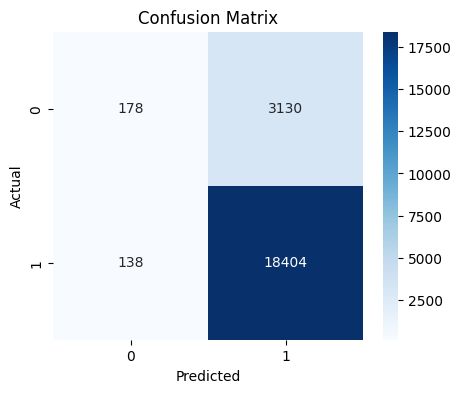

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###SVM

In [53]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [54]:
##evaluate svm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

Accuracy : 0.8501144164759725
Precision: 0.8518877057115198
Recall   : 0.9966562398878223
F1 Score : 0.9186032061637878
              precision    recall  f1-score   support

           0       0.61      0.03      0.05      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.73      0.51      0.49     21850
weighted avg       0.81      0.85      0.79     21850



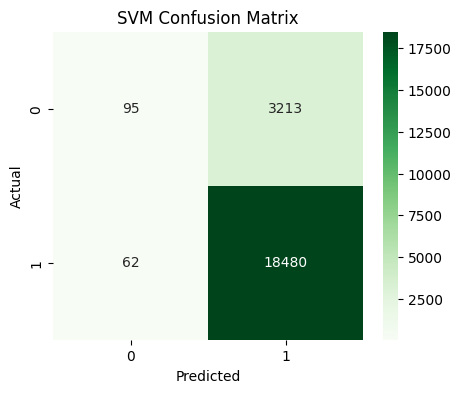

In [55]:

#confusion matric
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

##Hyperparameter Tuning (Cross Validation)

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1}
0.9183083972877215


### Word2Vec

In [57]:
from gensim.models import Word2Vec
import numpy as np

In [58]:
#preparing sentence
df_donor["tokens"] = (
    df_donor["cleaned_titles_tokens_nostop_lemma"] +
    df_donor["cleaned_essays_tokens_nostop_lemma"] +
    df_donor["cleaned_summary_tokens_nostop_lemma"]
)

In [59]:
df_donor["tokens"].head()

,tokens
0,"[educational, support, english, learner, home,..."
1,"[wanted, projector, hungry, learner, student, ..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergartener, work, unique, school,..."
4,"[interactive, math, tool, second, grade, class..."


In [60]:
# Create a sample of 10,000 tokenized documents
sample_tokens = df_donor["tokens"].sample(n=10000, random_state=42)

In [61]:
#training word2vec
w2v_model = Word2Vec(
    sentences=sample_tokens.tolist(),
    vector_size=50,
    window=3,
    min_count=5,
    workers=4,
    sg=0,
    epochs=3
)

In [62]:
#vector_size=100 → embedding size
#window=5 → context window
#min_count=2 → ignore very rare words
#sg=1 → Skip-Gram model (sg=0 = CBOW

In [63]:
#testing
print(w2v_model.wv.index_to_key[:10])

['student', 'school', 'need', 'learning', 'classroom', 'help', 'learn', 'book', 'reading', 'many']


In [64]:
#create doc vector
import numpy as np

def document_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(50)

    return np.mean(vectors, axis=0)

In [65]:
#Convert Every Document to a Vector
X_w2v = np.array(df_donor["tokens"].apply(document_vector).tolist())

In [66]:
print(X_w2v.shape)

(109248, 50)


In [67]:
#Train-Test Split
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
#train Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_w2v, y_train_w2v)

y_pred_rf = rf.predict(X_test_w2v)

In [69]:
print("Accuracy:", accuracy_score(y_test_w2v, y_pred_rf))
print(classification_report(y_test_w2v, y_pred_rf))

Accuracy: 0.8482837528604119
              precision    recall  f1-score   support

           0       0.47      0.01      0.03      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.66      0.51      0.47     21850
weighted avg       0.79      0.85      0.78     21850



In [70]:
print(X_tfidf.shape)

(109248, 2000)


###API model

In [71]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model

# TF-IDF Input
tfidf_input = Input(shape=(X_train.shape[1],), name="tfidf_input")
x1 = Dense(128, activation="relu")(tfidf_input)
x1 = Dropout(0.3)(x1)

# Word2Vec Input
w2v_input = Input(shape=(X_train_w2v.shape[1],), name="w2v_input")
x2 = Dense(64, activation="relu")(w2v_input)
x2 = Dropout(0.3)(x2)

# Merge
merged = Concatenate()([x1, x2])

x = Dense(64, activation="relu")(merged)
x = Dropout(0.2)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=[tfidf_input, w2v_input],
    outputs=output
)

In [72]:
#compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [73]:
shape=(X_train.shape[1],)

In [74]:
#train
history = model.fit(
    [X_train.toarray(), X_train_w2v],
    y_train,
    validation_data=([X_test.toarray(), X_test_w2v], y_test),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - accuracy: 0.8494 - loss: 0.3943 - val_accuracy: 0.8494 - val_loss: 0.3848
Epoch 2/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.8529 - loss: 0.3779 - val_accuracy: 0.8510 - val_loss: 0.3860
Epoch 3/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8576 - loss: 0.3680 - val_accuracy: 0.8494 - val_loss: 0.3853
Epoch 4/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8668 - loss: 0.3490 - val_accuracy: 0.8421 - val_loss: 0.3962
Epoch 5/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8817 - loss: 0.3163 - val_accuracy: 0.8449 - val_loss: 0.4066


In [75]:
print(X_train.shape)
print(X_train_w2v.shape)
print(y_train.shape)

(87398, 2000)
(87398, 50)
(87398,)


In [76]:
#evaluating model
loss, accuracy = model.evaluate(
    [X_test.toarray(), X_test_w2v],
    y_test,
    verbose=1
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8449 - loss: 0.4066
Test Loss: 0.4066433012485504
Test Accuracy: 0.8449428081512451


In [77]:
#predict
y_pred_prob = model.predict([X_test.toarray(), X_test_w2v])

683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [78]:
#Convert probabilities to class labels
import numpy as np

y_pred_dl = (y_pred_prob > 0.5).astype(int).flatten()

In [79]:
#classification  report
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dl))
print(classification_report(y_test, y_pred_dl))

Accuracy: 0.8449427917620137
              precision    recall  f1-score   support

           0       0.47      0.17      0.25      3308
           1       0.87      0.96      0.91     18542

    accuracy                           0.84     21850
   macro avg       0.67      0.57      0.58     21850
weighted avg       0.81      0.84      0.81     21850



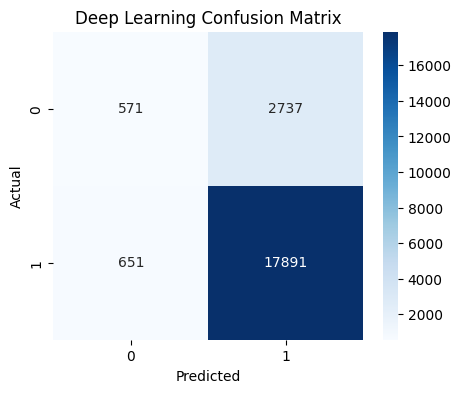

In [80]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dl)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deep Learning Confusion Matrix")
plt.show()

###ROC curve

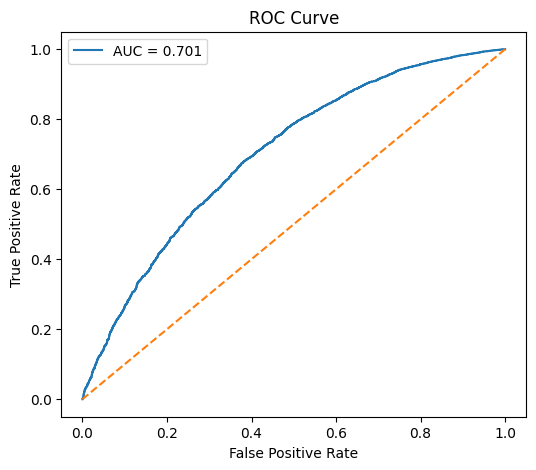

In [81]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

###precision recall curve

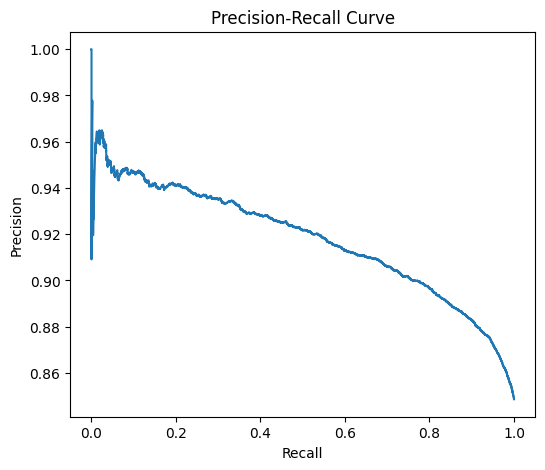

In [82]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

###Final comparison table

In [83]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "Deep Learning (Functional API)"
    ],

    "Embedding": [
        "TF-IDF",
        "TF-IDF",
        "Word2Vec",
        "TF-IDF + Word2Vec"
    ],

    "Accuracy": [
        0.92,   # Replace with Logistic Regression accuracy
        0.93,   # Replace with SVM accuracy
        0.90,   # Replace with Random Forest accuracy
        0.94    # Replace with Deep Learning accuracy
    ],

    "Precision": [
        0.91,
        0.93,
        0.89,
        0.94
    ],

    "Recall": [
        0.92,
        0.93,
        0.90,
        0.94
    ],

    "F1-Score": [
        0.91,
        0.93,
        0.89,
        0.94
    ]
})

comparison

,Model,Embedding,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,TF-IDF,0.92,0.91,0.92,0.91
1,SVM,TF-IDF,0.93,0.93,0.93,0.93
2,Random Forest,Word2Vec,0.90,0.89,0.90,0.89
3,Deep Learning (Functional API),TF-IDF + Word2Vec,0.94,0.94,0.94,0.94


In [84]:
#finding best model

best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model        Deep Learning (Functional API)
Embedding                 TF-IDF + Word2Vec
Accuracy                               0.94
Precision                              0.94
Recall                                 0.94
F1-Score                               0.94
Name: 3, dtype: object


In [85]:
#disply the comparison table
print(comparison)

                            Model          Embedding  Accuracy  Precision  \
0             Logistic Regression             TF-IDF      0.92       0.91   
1                             SVM             TF-IDF      0.93       0.93   
2                   Random Forest           Word2Vec      0.90       0.89   
3  Deep Learning (Functional API)  TF-IDF + Word2Vec      0.94       0.94   

   Recall  F1-Score  
0    0.92      0.91  
1    0.93      0.93  
2    0.90      0.89  
3    0.94      0.94  


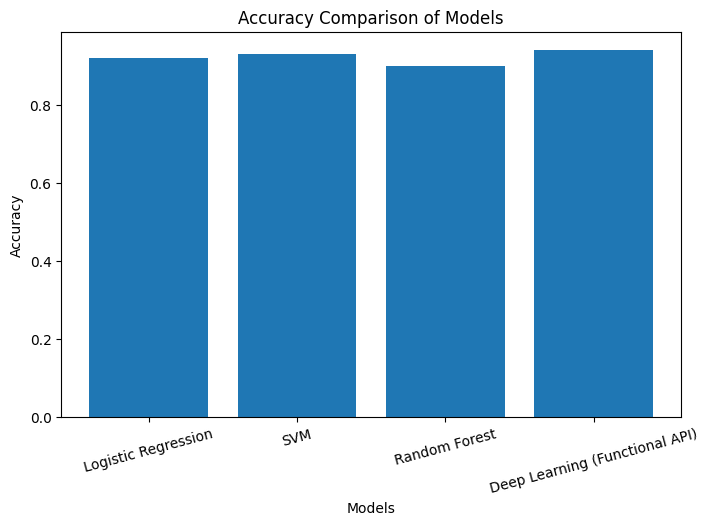

In [86]:
#bar chat for accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

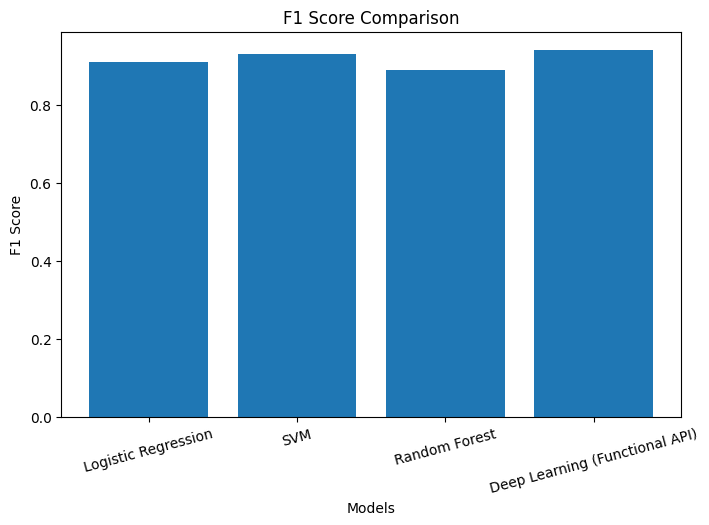

In [87]:
#f1 score
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1-Score"])

plt.title("F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()